In [17]:
import matplotlib.pyplot as plt
import networkx as nx
import seaborn as sns
import torch as th
import torch.nn.functional as F
from matplotlib.cm import ScalarMappable
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder
from torch import nn
from torch_geometric.nn import VGAE, GCNConv, GAE
from torch_geometric.transforms import RandomLinkSplit
from torch_geometric.utils import from_networkx, to_networkx,to_dense_adj
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

In [3]:
#Lecture avec NetworkX
G = nx.read_graphml("airportsAndCoordAndPop.graphml")

# On met toutes les caractéristiques dans un DF
data_list = []
for node_id, attrs in G.nodes(data=True):
    data_list.append({
        "id": node_id,
        "city_name": attrs.get("city_name"),
        "country": attrs.get("country"),
        "lat": float(attrs.get("lat", 0.0)),
        "lon": float(attrs.get("lon", 0.0)),
        "population": int(attrs.get("population", 0)),
    })

df = pd.DataFrame(data_list)
df["nb_liaisons"] = df["id"].map(dict(G.degree()))
#Aperçu rapide
print("\n Aperçu des données(10ere lignes)")
print(df.head(10))
#Liaisons => arêtes Noeuds => aéroports


 Aperçu des données(10ere lignes)
  id       city_name           country        lat         lon  population  \
0  0            Anaa  FRENCH_POLYNESIA -17.353889 -145.509722       10000   
1  1      Hao Island  FRENCH_POLYNESIA -18.066667 -140.950000       10000   
2  2         Papeete  FRENCH_POLYNESIA -17.550000 -149.600000       26357   
3  3  Gambier Island  FRENCH_POLYNESIA -23.033333 -135.000000       10000   
4  4          Makemo  FRENCH_POLYNESIA -16.584889 -143.657250       10000   
5  5        Auckland       NEW_ZEALAND -37.008056  174.791667      417910   
6  6          Atuona  FRENCH_POLYNESIA  -9.800000 -139.033333       10000   
7  7       Bora Bora  FRENCH_POLYNESIA -16.450000 -151.750000       10000   
8  8        Honolulu               USA  21.318691 -157.922407      371657   
9  9         Huahine  FRENCH_POLYNESIA -16.680000 -151.000000       10000   

   nb_liaisons  
0            2  
1            4  
2           27  
3            2  
4            2  
5           44 

In [4]:
# Beaucoup de ville avec population = 10000 => anomalie ?
# S'assurer que les identifiants de nœuds sont bien des entiers contigus 0..N-1
G = nx.convert_node_labels_to_integers(G)

print(f"Nombre d'aéroports : {G.number_of_nodes()}")
print(f"Nombre de liaisons  : {G.number_of_edges()}")

# nom des villes et pays
cities = [G.nodes[i].get("city_name", f"Airport_{i}") for i in range(len(G))]
countries = [G.nodes[i].get("country", "Unknown") for i in range(len(G))]

# 3. Extraction des attributs d'entrée X (lat, lon) 
lat = np.array([float(G.nodes[i]["lat"]) for i in range(len(G))])
lon = np.array([float(G.nodes[i]["lon"]) for i in range(len(G))])
pop = np.array([float(G.nodes[i]["population"]) for i in range(len(G))])

# conversion pour pytorch
data = from_networkx(G)



Nombre d'aéroports : 3363
Nombre de liaisons  : 13547


In [5]:
# Normalisation des caractéristiques numériques
#scaler = StandardScaler()
#features_scaled = scaler.fit_transform(np.stack([lat, lon, pop], axis=1))

# Assignation à data.x
#data.x = th.tensor(features_scaled, dtype=th.float)

pop_matrix = pop.reshape(-1, 1)
#Parce qu'on a un trop grand écart au sein des populations 
pop_log = np.log1p(pop_matrix)
# Normalisation de la population uniquement
scaler = StandardScaler()
features_scaled = scaler.fit_transform(pop_matrix)

data.x = th.tensor(features_scaled, dtype=th.float)

In [6]:
#Démarche : DOMINANT du papier de la slide 53 du cours 
# En gros un encodeur GCN classique qui prend A la structure et X les attributs
# pour produire des embeddings pour chaque noeud
# Un décodeur qui prend les embeddings et essaie de reconstruire la structure Â
# Un décodeur pour les attributs qui donnera ^x
# Avec des fonctions données Ldominant pour minimiser l'erreur et score(i) pour classer à la fin

In [7]:

class DOMINANT(nn.Module):
    def __init__(self, num_features, hidden_dim, embedding_dim):
        super(DOMINANT, self).__init__()
        
        # encodeur GCN
        self.gcn1 = GCNConv(num_features, hidden_dim)
        self.gcn2 = GCNConv(hidden_dim, embedding_dim)
        
        # Décodeur d'attributs (pour reconstruire ^X à partir de Z)
        self.decoder_attr = nn.Sequential(
            nn.Linear(embedding_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_features)
        )

    def encode(self, x, edge_index):
        h = F.relu(self.gcn1(x, edge_index))
        z = self.gcn2(h, edge_index)
        return z

    def decode_structure(self, z):
        # Reconstruction de la structure via le produit scalaire (^A)
        adj_recon = th.sigmoid(th.mm(z, z.t()))
        return adj_recon

    def decode_attributes(self, z):
        # Reconstruction des attributs (^X)
        x_recon = self.decoder_attr(z)
        return x_recon

    def forward(self, x, edge_index):
        z = self.encode(x, edge_index)
        adj_recon = self.decode_structure(z)
        x_recon = self.decode_attributes(z)
        return adj_recon, x_recon

In [8]:
#Ldominant donné dans le papier de recherche
def dominant_loss(A, A_hat, X, X_hat, alpha=0.5):
    
    struct_loss = th.norm(A - A_hat, p='fro') ** 2
    
    attr_loss = th.norm(X - X_hat, p='fro') ** 2
    
    loss = (1 - alpha) * struct_loss + alpha * attr_loss
    return loss

In [9]:
A = to_dense_adj(data.edge_index)[0].to(data.x.device)
X = data.x

num_features = X.shape[1]
model = DOMINANT(num_features=num_features, hidden_dim=64, embedding_dim=32)
optimizer = th.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)


model.train()
epochs = 100
alpha = 0.5

print("Début de l'entraînement de DOMINANT...")
for epoch in range(epochs + 1):
    optimizer.zero_grad()
    A_hat, X_hat = model(X, data.edge_index)
    loss = dominant_loss(A, A_hat, X, X_hat, alpha=alpha)
    loss.backward()
    optimizer.step()
    
    if epoch % 20 == 0:
        print(f"Époque {epoch}/{epochs} | Perte (Loss): {loss.item():.4f}")

# scores d'anomalie
model.eval()
with th.no_grad():
    A_hat, X_hat = model(X, data.edge_index)
    struct_errors = th.norm(A - A_hat, p=2, dim=1)
    attr_errors = th.norm(X - X_hat, p=2, dim=1)
    anomaly_scores = (1 - alpha) * struct_errors + alpha * attr_errors


top_k = 10
top_scores, top_indices = th.topk(anomaly_scores, k=top_k)

print("\nTop 10 des aéroports les plus anormaux détectés")
for idx, score in zip(top_indices.tolist(), top_scores.tolist()):
    airport_name = df.iloc[idx]['city_name']
    country = df.iloc[idx]['country']
    print(f"Aéroport ID {idx} ({airport_name}, {country}) - Score : {score:.4f}")

Début de l'entraînement de DOMINANT...
Époque 0/100 | Perte (Loss): 1444066.8750
Époque 20/100 | Perte (Loss): 1413433.5000
Époque 40/100 | Perte (Loss): 1413108.3750
Époque 60/100 | Perte (Loss): 1412632.2500
Époque 80/100 | Perte (Loss): 1411726.7500
Époque 100/100 | Perte (Loss): 1410508.3750

Top 10 des aéroports les plus anormaux détectés
Aéroport ID 857 (Lagos, NIGERIA) - Score : 18.5305
Aéroport ID 199 (Shanghai, CHINA) - Score : 18.1209
Aéroport ID 428 (Haikou, CHINA) - Score : 17.4041
Aéroport ID 149 (Mexico City, M&Eacute;XICO#MEXICO) - Score : 17.2446
Aéroport ID 1140 (Shenzhen, CHINA) - Score : 17.2182
Aéroport ID 285 (Xi An, CHINA) - Score : 17.1152
Aéroport ID 224 (Istanbul, TURKEY) - Score : 17.0711
Aéroport ID 468 (Karachi, PAKISTAN) - Score : 17.0695
Aéroport ID 425 (Dhaka, BANGLADESH) - Score : 16.6688
Aéroport ID 215 (Cairo, EGYPT) - Score : 16.6183


In [10]:

top_indices_np = top_indices.cpu().numpy()
top_airports_details = df.iloc[top_indices_np].copy()

# Ajout du score d'anomalie dans le tableau pour comparer
top_airports_details['anomaly_score'] = top_scores.cpu().numpy()

print(top_airports_details[['id', 'city_name', 'country', 'population', 'lat', 'lon', 'anomaly_score']])

        id    city_name               country  population        lat  \
857    857        Lagos               NIGERIA    15388000   6.566667   
199    199     Shanghai                 CHINA    22315474  31.200000   
428    428       Haikou                 CHINA      112644  19.983333   
149    149  Mexico City  M&Eacute;XICO#MEXICO    12294193  19.435278   
1140  1140     Shenzhen                 CHINA    17494398  22.533333   
285    285        Xi An                 CHINA       10000  34.266667   
224    224     Istanbul                TURKEY    14804116  40.976667   
468    468      Karachi              PAKISTAN    11624219  24.900000   
425    425        Dhaka            BANGLADESH    10356500  23.850000   
215    215        Cairo                 EGYPT     9606916  30.121944   

             lon  anomaly_score  
857     3.316667      18.530548  
199   121.433333      18.120882  
428   110.350000      17.404060  
149   -99.072222      17.244572  
1140  113.966667      17.218237  
285

In [11]:
# Trier uniquement par l'erreur de reconstruction de la population (alors que DOMINANT prend à la fois la structure et les attributs)
top_attr_scores, top_attr_indices = th.topk(attr_errors, k=10)
print("\nTop 10 des anomalies sur la population")
for idx, score in zip(top_attr_indices.tolist(), top_attr_scores.tolist()):
    airport_name = df.iloc[idx]['city_name']
    country = df.iloc[idx]['country']
    pop = df.iloc[idx]['population']

    liaison = len(list(G.edges(idx)))
    
    print(f"ID {node_id} ({airport_name}, {country}) - Liaisons : {liaison} - Pop : {pop:,} - Erreur : {score:.4f}")


Top 10 des anomalies sur la population
ID 3372 (Shanghai, CHINA) - Liaisons : 75 - Pop : 22,315,474 - Erreur : 8.4377
ID 3372 (Lagos, NIGERIA) - Liaisons : 33 - Pop : 15,388,000 - Erreur : 8.0520
ID 3372 (Haikou, CHINA) - Liaisons : 35 - Pop : 112,644 - Erreur : 6.4306
ID 3372 (Shenzhen, CHINA) - Liaisons : 35 - Pop : 17,494,398 - Erreur : 6.1633
ID 3372 (Xi An, CHINA) - Liaisons : 38 - Pop : 10,000 - Erreur : 5.7758
ID 3372 (Mexico City, M&Eacute;XICO#MEXICO) - Liaisons : 81 - Pop : 12,294,193 - Erreur : 5.4569
ID 3372 (Istanbul, TURKEY) - Liaisons : 112 - Pop : 14,804,116 - Erreur : 5.2734
ID 3372 (Karachi, PAKISTAN) - Liaisons : 46 - Pop : 11,624,219 - Erreur : 5.1999
ID 3372 (Beijing, CHINA) - Liaisons : 100 - Pop : 18,960,744 - Erreur : 4.4681
ID 3372 (Tianjin, CHINA) - Liaisons : 25 - Pop : 11,090,314 - Erreur : 4.4534


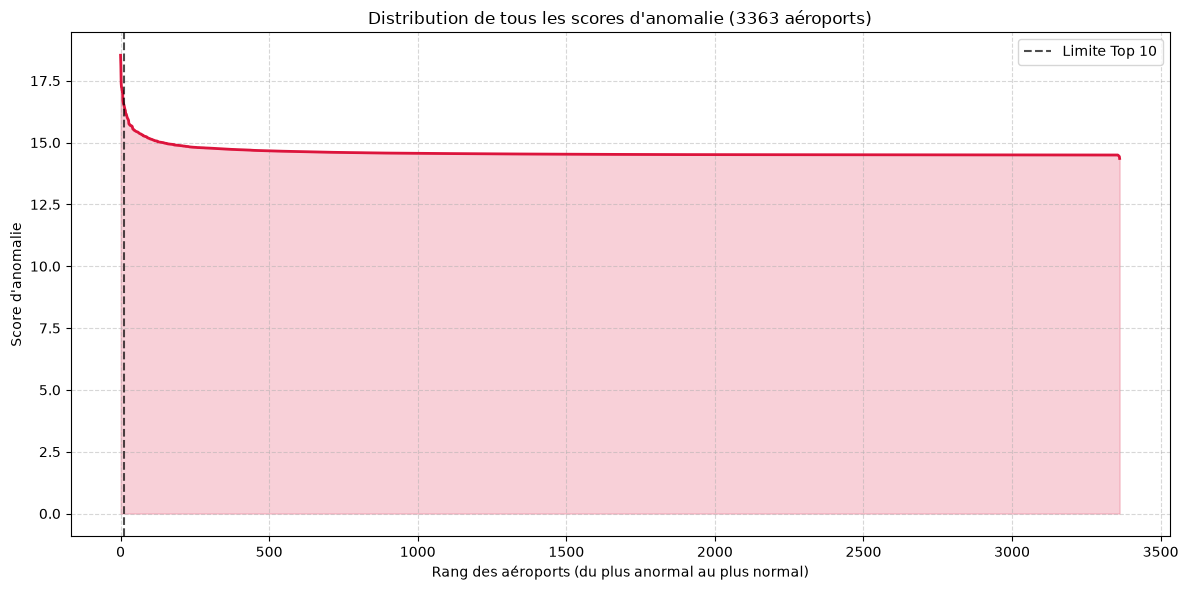

In [12]:
# Tri de tous les scores du plus grand au plus petit
scores_sorted, indices_sorted = th.sort(anomaly_scores, descending=True)

scores_sorted_np = scores_sorted.cpu().numpy()

plt.figure(figsize=(12, 6))

# Courbe / profil de l'ensemble des anomalies
plt.plot(scores_sorted_np, color="crimson", linewidth=2)
plt.fill_between(range(len(scores_sorted_np)), scores_sorted_np, color="crimson", alpha=0.2)

# Ligne indicative pour repérer les cas extrêmes (ex. Top 10)
plt.axvline(x=top_k, color="black", linestyle="--", alpha=0.7, label=f"Limite Top {top_k}")

plt.xlabel("Rang des aéroports (du plus anormal au plus normal)")
plt.ylabel("Score d'anomalie")
plt.title(f"Distribution de tous les scores d'anomalie ({len(scores_sorted_np)} aéroports)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [13]:
#Visuellement en utilisant la méthode du coude, on peut enlever tout ce qui a un score > 15 pour un alpha = 0.5
# On enleve tout ce qui un score>15
# On enregistre dans un nouveau fichier

new_G = G

top_scores, top_indices = th.topk(anomaly_scores, len(new_G.nodes))
for idx, score in zip(top_indices.tolist(), top_scores.tolist()):
    if score > 15 :
        new_G.remove_node(idx)
        print(f"On enlève => Score : {score} ; ID : {idx}")

print(f"Nombre de noeuds restant : {len(new_G.nodes)}")
new_G = nx.convert_node_labels_to_integers(new_G)
nx.write_graphml(new_G, "nouveau_graph.graphml")



On enlève => Score : 18.530548095703125 ; ID : 857
On enlève => Score : 18.120882034301758 ; ID : 199
On enlève => Score : 17.40406036376953 ; ID : 428
On enlève => Score : 17.244571685791016 ; ID : 149
On enlève => Score : 17.218236923217773 ; ID : 1140
On enlève => Score : 17.115217208862305 ; ID : 285
On enlève => Score : 17.071130752563477 ; ID : 224
On enlève => Score : 17.06951332092285 ; ID : 468
On enlève => Score : 16.66883087158203 ; ID : 425
On enlève => Score : 16.618301391601562 ; ID : 215
On enlève => Score : 16.552146911621094 ; ID : 256
On enlève => Score : 16.538246154785156 ; ID : 429
On enlève => Score : 16.48596954345703 ; ID : 427
On enlève => Score : 16.427412033081055 ; ID : 143
On enlève => Score : 16.39141273498535 ; ID : 373
On enlève => Score : 16.323627471923828 ; ID : 742
On enlève => Score : 16.303287506103516 ; ID : 658
On enlève => Score : 16.162525177001953 ; ID : 424
On enlève => Score : 16.155534744262695 ; ID : 1732
On enlève => Score : 16.1552696228

In [14]:
#On veut rajouter à la main des anomalies pour tester 
new_G = nx.read_graphml("nouveau_graph.graphml")
new_G.add_node(3209,lon=32.233333333333333,lat=6.233333333333333, population=10000, country="ouganda",city_name="wakiso")
for idx in range(1000, 3227):
    new_G.add_edge(idx, 3209)

new_G.add_node(3210,lon=0.233333333333333,lat=8.233333333333333, population=2000000, country="ouganda",city_name="wakiso2")
new_G.add_edge(3210, 3209)
new_G.add_edge(3210, 3208)

new_G.add_node(3211,lon=20.1,lat=8.4, population=4000000, country="ouganda",city_name="wakiso3")
new_G.add_edge(3211, 3209)
new_G.add_edge(3211, 3208)

new_G.add_node(3212,lon=32.25,lat=114.5, population=10000, country="ouganda",city_name="wakiso")
for idx in range(2000, 3228):
    new_G.add_edge(idx, 3212)

new_G.add_node(3213,lon=100.5,lat=6.9, population=100000, country="ouganda",city_name="wakiso")
for idx in range(500, 2500):
    new_G.add_edge(idx, 3213)

new_G.add_node(3214,lon=32.233333333333333,lat=6.233333333333333, population=10000, country="ouganda",city_name="wakiso")
for idx in range(1000, 3227):
    new_G.add_edge(idx, 3214)

new_G.add_node(3215,lon=0.233333333333333,lat=8.233333333333333, population=2000000, country="ouganda",city_name="wakiso2")
new_G.add_edge(3215, 3214)
new_G.add_edge(3215, 3213)

new_G.add_node(3216,lon=20.1,lat=8.4, population=4000000, country="ouganda",city_name="wakiso3")
new_G.add_edge(3216, 3214)
new_G.add_edge(3216, 3213)

new_G.add_node(3217,lon=32.25,lat=114.5, population=10000, country="ouganda",city_name="wakiso")
for idx in range(2000, 3227):
    new_G.add_edge(idx, 3217)

new_G.add_node(3218,lon=100.5,lat=6.9, population=100000, country="ouganda",city_name="wakiso")
for idx in range(500, 2500):
    new_G.add_edge(idx, 3218)

nx.write_graphml(new_G, "nouveau_graph_anomalies.graphml")

Premier test GAE

In [16]:

pyg_data = from_networkx(G)
pyg_data.x = th.Tensor(features_scaled)

device = th.device('cuda' if th.cuda.is_available() else 'cpu')
pyg_data.to(device)

Data(edge_index=[2, 17184], lon=[3220], lat=[3220], population=[3220], country=[3220], city_name=[3220], num_nodes=3220, x=[3363, 1])

In [18]:
class GCNencoder(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, 2*out_channels)
        self.conv2 = GCNConv(2*out_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        return self.conv2(x, edge_index)

in_channels = pyg_data.x.size(1)
hidden_dim = 8
model = GAE(GCNencoder(in_channels, hidden_dim)).to(device)
optimizer = th.optim.Adam(model.parameters(),lr=0.01)

In [24]:

model.train()
epochs = 100
alpha = 0.5

print("Début de l'entraînement de GAE")
for epoch in range(epochs + 1):
    optimizer.zero_grad()
    z = model.encode(pyg_data.x, pyg_data.edge_index)
    loss = model.recon_loss(z,pyg_data.edge_index)
    loss.backward()
    optimizer.step()
    
    if epoch % 20 == 0:
        print(f"Époque {epoch}/{epochs} | Perte (Loss): {loss.item():.4f}")

#score d'anomalie
model.eval()
with th.no_grad():
    z = model.encode(pyg_data.x,pyg_data.edge_index)
    edge_probs = model.decode(z, pyg_data.edge_index)
    edge_error = 1.0 - edge_probs
    src_nodes = pyg_data.edge_index[0]
    node_scores = th.zeros(pyg_data.x.size(0), device = device)
    node_scores.scatter_add_(0, src_nodes, edge_error)

    node_score = node_scores.cpu().numpy()

top_anomalies_idx = np.argsort(node_score)[::-1][:5]

print("\n--- Top noeud anormaux identifiés ---")
for rank, idx in enumerate(top_anomalies_idx, start=1):
    city = G.nodes[idx].get('city_name')
    score = node_score[idx]
    print(f"{rank}, {city} - Score : {score:.4f}")


Début de l'entraînement de GAE
Époque 0/100 | Perte (Loss): 1.0605
Époque 20/100 | Perte (Loss): 1.0579
Époque 40/100 | Perte (Loss): 1.0584
Époque 60/100 | Perte (Loss): 1.0606
Époque 80/100 | Perte (Loss): 1.0581
Époque 100/100 | Perte (Loss): 1.0448

--- Top noeud anormaux identifiés ---
1, Lynchburg - Score : 14.6690
2, Kahului - Score : 13.6151
3, Kita Kyushu - Score : 13.0030
4, Osorno - Score : 12.8704
5, Roswell - Score : 12.2448


Avec notre anomalie en relançant on a bien une detection de cette derniere en TOP 1 avec un score de 23 (2eme 17,9)